In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix, lil_matrix
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
import pyreadr 
from pathlib import Path
import os

os.chdir(Path.cwd().parent)


S = 1601, T = 2704
Posterior samples M = 1000

Running PPC for BYM...


PPC BYM: 100%|██████████| 1000/1000 [09:28<00:00,  1.76it/s]



Running PPC for IID...


PPC IID: 100%|██████████| 1000/1000 [07:17<00:00,  2.29it/s]


===== SPATIAL ONE-STEP-AHEAD PPC (POSTERIOR RANKING) =====

BYM:
  mean: 0.523
  sd: 0.104
  median: 0.519
  Pr(p < 0.05): 0.000
  Pr(p > 0.95): 0.000

IID:
  mean: 0.508
  sd: 0.090
  median: 0.510
  Pr(p < 0.05): 0.000
  Pr(p > 0.95): 0.000

===== P-VALUE DISTRIBUTION DIAGNOSTICS =====

BYM: KS test for uniformity: statistic=0.3114, p-value=0.0000
IID: KS test for uniformity: statistic=0.3014, p-value=0.0000

(If model fits well, p-values should be approximately uniform)

PPC results saved to:
D:\77\Research\temp\snow\ppc_timeavg_onestep_results_corrected.npz



P-value histogram saved to: D:\77\Research\temp\snow\ppc_pvalue_histogram.png


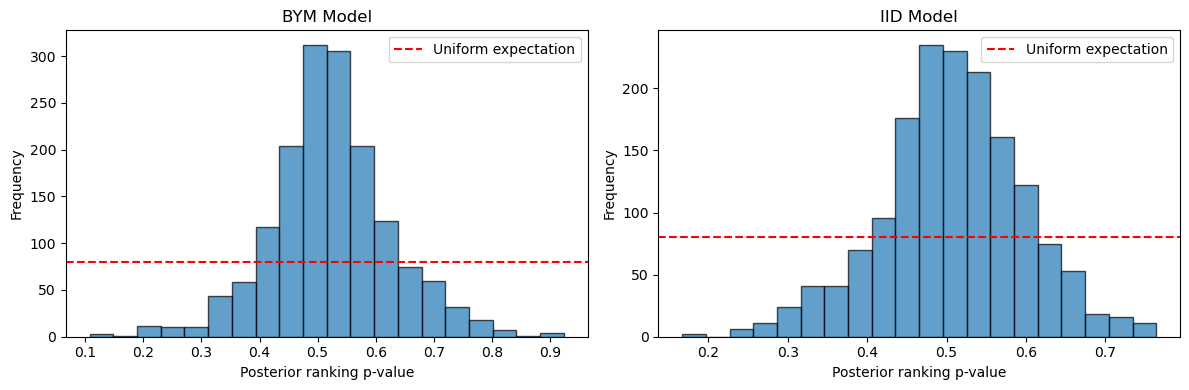

In [ ]:
# ================================================================
# PPC: Spatial one-step-ahead posterior-ranking p-values
#      Statistic: proportion of snowy days averaged across time
#      CORRECTED VERSION: Simulates replicated datasets
# ================================================================

import numpy as np
import pyreadr
from pathlib import Path
from tqdm import tqdm

# ================================================================
# 0. CONFIGURATION
# ================================================================
BASE_DIR = Path(r"D:\77\Research\temp\snow")
period = 52

# indices of isolated locations (0-based)
no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

# ================================================================
# 1. LOAD DATA AND REMOVE ISOLATED LOCATIONS
# ================================================================
# snow_cleaned_full.Rda:
#   rows   -> spatial locations
#   cols 2: -> binary snow indicator over time

snow = pyreadr.read_r("snow_cleaned_full.Rda")
snow = list(snow.values())[0]

# full response matrix (S_full x T)
y_full = snow.iloc[:, 2:].to_numpy()

# remove isolated locations
y = np.delete(y_full, no_nbs, axis=0)

# S = number of non-isolated locations
# T = number of time points
S, T = y.shape

print(f"S = {S}, T = {T}")

# ================================================================
# 2. OBSERVED STATISTIC
# ================================================================
# Statistic:
#   For each location i:
#   T_obs[i] = mean_{t=2..T} y_{i,t}
#
# We exclude t=1 (Python index 0) because
# one-step-ahead conditions on y_{i,t-1}

T_obs = y[:, 1:].mean(axis=1)   # shape (S,)

# ================================================================
# 3. LOAD POSTERIOR SAMPLES
# ================================================================
# BYM model (already fit on non-isolated locations)
bym01 = np.load(BASE_DIR / "bym01_noIso_final.npz")["all_theta"]
bym10 = np.load(BASE_DIR / "bym10_noIso_final.npz")["all_theta"]

# IID model (fit on full graph, need subsetting)
ind01_full = np.load(BASE_DIR / "ind01.npz")["all_theta"]
ind10_full = np.load(BASE_DIR / "ind10.npz")["all_theta"]

# number of posterior samples
M = bym01.shape[1]
print(f"Posterior samples M = {M}")

# ================================================================
# 4. EXTRACT NON-ISOLATED IID PARAMETERS
# ================================================================
# IID has K_iid = 4 covariates
# Parameter layout:
#   theta = [beta_1(location 1..S), beta_2(1..S), ...]

S_full = y_full.shape[0]
K_iid = 4

ind01 = np.zeros((K_iid * S, M))
ind10 = np.zeros((K_iid * S, M))

for k in range(K_iid):
    # take first S locations (non-isolated)
    ind01[k*S:(k+1)*S, :] = ind01_full[
        k*S_full : k*S_full + S, :
    ]
    ind10[k*S:(k+1)*S, :] = ind10_full[
        k*S_full : k*S_full + S, :
    ]

# ================================================================
# 5. BUILD COVARIATE MATRICES
# ================================================================
# Time index: t = 1,...,T
t_raw = np.arange(1, T + 1)

# IMPORTANT: same scaling rule as in run_bym()
t_trend = (t_raw - t_raw.mean()) / t_raw.std()

# BYM covariates (8 columns)
cov_bym = np.column_stack([
    np.ones(T), np.ones(T),
    np.cos(2*np.pi*t_raw/period), np.cos(2*np.pi*t_raw/period),
    np.sin(2*np.pi*t_raw/period), np.sin(2*np.pi*t_raw/period),
    t_trend, t_trend
])

# IID uses single set
cov_iid = np.column_stack([
    np.ones(T),
    np.cos(2*np.pi*t_raw/period),
    np.sin(2*np.pi*t_raw/period),
    t_raw
])   # shape (T, 4)

# ================================================================
# 6. PPC FOR BYM MODEL (CORRECTED WITH SIMULATION)
# ================================================================
print("\nRunning PPC for BYM...")

# storage for predicted statistics
T_pred_bym = np.zeros((M, S))

for m in tqdm(range(M), desc="PPC BYM"):
    # Initialize replicated dataset
    y_rep = np.zeros((S, T), dtype=int)
    y_rep[:, 0] = y[:, 0]  # use observed initial state
    
    # Simulate forward in time
    for t in range(1, T):
        # Compute linear predictors
        eta01 = np.zeros(S)
        eta10 = np.zeros(S)
        
        K = 8
        for k in range(K):
            eta01 += cov_bym[t, k] * bym01[k*S:(k+1)*S, m]
            eta10 += cov_bym[t, k] * bym10[k*S:(k+1)*S, m]
        
        # Transition probabilities
        p01 = 1.0 / (1.0 + np.exp(-eta01))
        p10 = 1.0 / (1.0 + np.exp(-eta10))
        
        # Sample next state based on previous state (vectorized)
        prev_state = y_rep[:, t-1]
        prob_snow = np.where(prev_state == 0, p01, 1.0 - p10)
        
        # Simulate binary outcomes
        y_rep[:, t] = np.random.binomial(1, prob_snow)
    
    # Compute statistic on replicated data
    T_pred_bym[m, :] = y_rep[:, 1:].mean(axis=1)

# Posterior-ranking p-values
p_loc_bym = np.mean(T_obs[None, :] > T_pred_bym, axis=0)

sum_bym = {
    "mean": p_loc_bym.mean(),
    "sd": p_loc_bym.std(),
    "median": np.median(p_loc_bym),
    "Pr(p < 0.05)": np.mean(p_loc_bym < 0.05),
    "Pr(p > 0.95)": np.mean(p_loc_bym > 0.95),
}

# ================================================================
# 7. PPC FOR IID MODEL (CORRECTED WITH SIMULATION)
# ================================================================
print("\nRunning PPC for IID...")

T_pred_iid = np.zeros((M, S))

for m in tqdm(range(M), desc="PPC IID"):
    # Initialize replicated dataset
    y_rep = np.zeros((S, T), dtype=int)
    y_rep[:, 0] = y[:, 0]  # use observed initial state
    
    # Simulate forward in time
    for t in range(1, T):
        # Compute linear predictors
        eta01 = np.zeros(S)
        eta10 = np.zeros(S)
        
        K = 4
        for k in range(K):
            eta01 += cov_iid[t, k] * ind01[k*S:(k+1)*S, m]
            eta10 += cov_iid[t, k] * ind10[k*S:(k+1)*S, m]
        
        # Transition probabilities
        p01 = 1.0 / (1.0 + np.exp(-eta01))
        p10 = 1.0 / (1.0 + np.exp(-eta10))
        
        # Sample next state based on previous state (vectorized)
        prev_state = y_rep[:, t-1]
        prob_snow = np.where(prev_state == 0, p01, 1.0 - p10)
        
        # Simulate binary outcomes
        y_rep[:, t] = np.random.binomial(1, prob_snow)
    
    # Compute statistic on replicated data
    T_pred_iid[m, :] = y_rep[:, 1:].mean(axis=1)

# Posterior-ranking p-values
p_loc_iid = np.mean(T_obs[None, :] > T_pred_iid, axis=0)

sum_iid = {
    "mean": p_loc_iid.mean(),
    "sd": p_loc_iid.std(),
    "median": np.median(p_loc_iid),
    "Pr(p < 0.05)": np.mean(p_loc_iid < 0.05),
    "Pr(p > 0.95)": np.mean(p_loc_iid > 0.95),
}

# ================================================================
# 8. PRINT SUMMARY
# ================================================================
print("\n===== SPATIAL ONE-STEP-AHEAD PPC (POSTERIOR RANKING) =====\n")

print("BYM:")
for k, v in sum_bym.items():
    print(f"  {k}: {v:.3f}")

print("\nIID:")
for k, v in sum_iid.items():
    print(f"  {k}: {v:.3f}")

# ================================================================
# 9. ADDITIONAL DIAGNOSTIC: HISTOGRAM OF P-VALUES
# ================================================================
print("\n===== P-VALUE DISTRIBUTION DIAGNOSTICS =====\n")

# Kolmogorov-Smirnov test for uniformity (informal check)
from scipy.stats import kstest

ks_bym = kstest(p_loc_bym, 'uniform')
ks_iid = kstest(p_loc_iid, 'uniform')

print(f"BYM: KS test for uniformity: statistic={ks_bym.statistic:.4f}, p-value={ks_bym.pvalue:.4f}")
print(f"IID: KS test for uniformity: statistic={ks_iid.statistic:.4f}, p-value={ks_iid.pvalue:.4f}")
print("\n(If model fits well, p-values should be approximately uniform)")

# ================================================================
# 10. SAVE PPC RESULTS (FOR LATER PLOTTING)
# ================================================================
out_file = BASE_DIR / "ppc_timeavg_onestep_results_corrected.npz"

np.savez(
    out_file,
    p_loc_bym=p_loc_bym,   # (S,)
    p_loc_iid=p_loc_iid,   # (S,)
    T_obs=T_obs,           # (S,)
    T_pred_bym=T_pred_bym, # (M, S) - full predictive distribution
    T_pred_iid=T_pred_iid, # (M, S) - full predictive distribution
    sum_bym=sum_bym,       # dict (metadata)
    sum_iid=sum_iid        # dict (metadata)
)

print(f"\nPPC results saved to:\n{out_file}")

# ================================================================
# 11. QUICK VISUALIZATION OF P-VALUE DISTRIBUTION
# ================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(p_loc_bym, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Posterior ranking p-value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('BYM Model')
axes[0].legend()

axes[1].hist(p_loc_iid, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Posterior ranking p-value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('IID Model')
axes[1].legend()

plt.tight_layout()
plt.savefig(BASE_DIR / "ppc_pvalue_histogram.png", dpi=300, bbox_inches='tight')
print(f"\nP-value histogram saved to: {BASE_DIR / 'ppc_pvalue_histogram.png'}")
plt.show()

Loaded PPC results.
Number of locations: 1601
NH locations: 1601


C:\Users\lix23\AppData\Local\Temp\ipykernel_12088\1077093696.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])



Map saved to: D:\77\Research\temp\snow\ppc_spatial_map_corrected.png


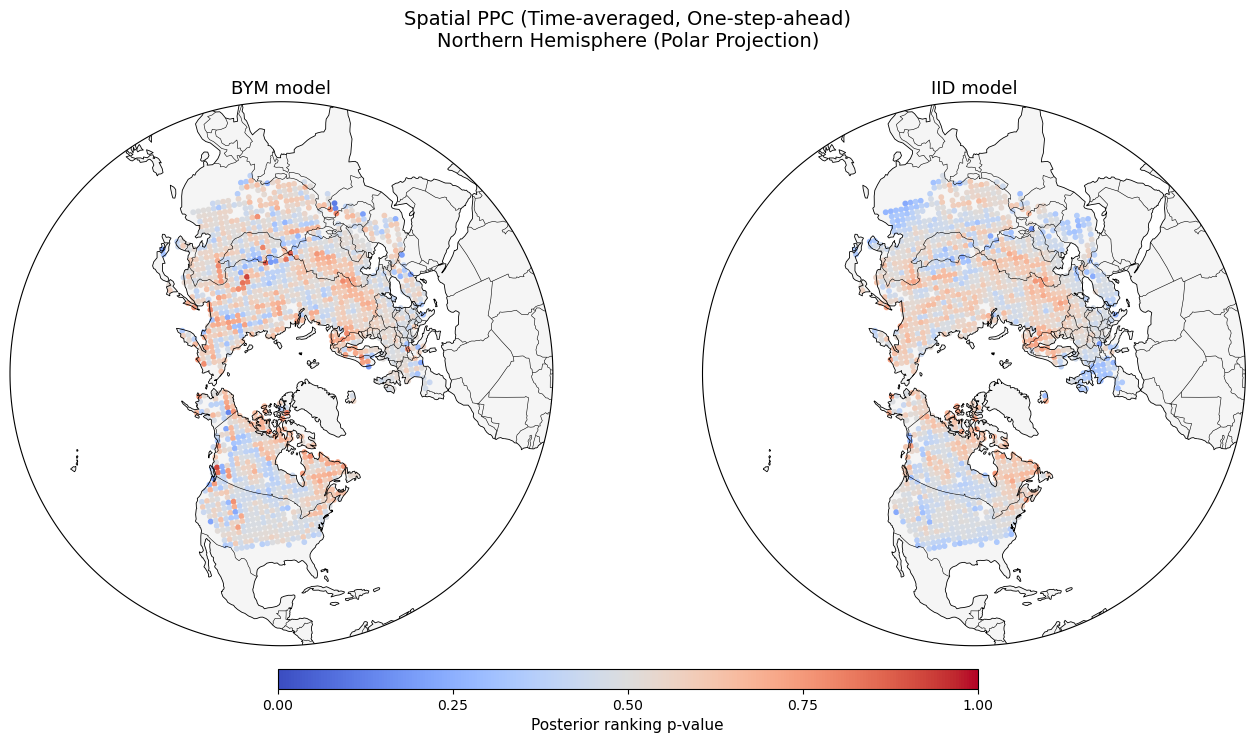

In [5]:
# ================================================================
# PLOT PPC MAPS (BYM vs IID)
# Spatial PPC (time-averaged, one-step-ahead)
# Northern Hemisphere, polar projection
# ================================================================

import numpy as np
import pyreadr
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath

# ================================================================
# 0. PATHS & CONFIG
# ================================================================
BASE_DIR = Path(r"D:\77\Research\temp\snow")

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

# ================================================================
# 1. LOAD PPC RESULTS (CORRECTED VERSION)
# ================================================================
ppc = np.load(
    BASE_DIR / "ppc_timeavg_onestep_results_corrected.npz",
    allow_pickle=True
)

p_loc_bym = ppc["p_loc_bym"]    # (S,)
p_loc_iid = ppc["p_loc_iid"]    # (S,)

print("Loaded PPC results.")
print("Number of locations:", p_loc_bym.shape[0])

# ================================================================
# 2. LOAD COORDINATES (MATCH PPC ORDER)
# ================================================================
snow = pyreadr.read_r(BASE_DIR / "snow_cleaned_full.Rda")
snow = list(snow.values())[0]

coords_full = snow.iloc[:, :2].to_numpy()
coords = np.delete(coords_full, no_nbs, axis=0)

lon = coords[:, 0]
lat = coords[:, 1]

assert lon.shape[0] == p_loc_bym.shape[0]

# ================================================================
# 3. KEEP NORTHERN HEMISPHERE ONLY
# ================================================================
mask_nh = lat > 0

lon_nh = lon[mask_nh]
lat_nh = lat[mask_nh]

p_bym_nh = p_loc_bym[mask_nh]
p_iid_nh = p_loc_iid[mask_nh]

print("NH locations:", lon_nh.shape[0])

# ================================================================
# 4. SET UP POLAR PROJECTION (ROTATED)
# ================================================================
proj = ccrs.NorthPolarStereo(central_longitude=-90)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 7),
    subplot_kw=dict(projection=proj)
)

# circular clip path (shared)
theta = np.linspace(0, 2*np.pi, 400)
verts = np.vstack([
    0.5 + 0.5 * np.cos(theta),
    0.5 + 0.5 * np.sin(theta)
]).T
circle_path = mpath.Path(verts)

# ================================================================
# 5. DRAW EACH PANEL
# ================================================================
for ax, pvals, title in zip(
    axes,
    [p_bym_nh, p_iid_nh],
    ["BYM model", "IID model"]
):

    # polar cap only
    ax.set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())
    ax.set_boundary(circle_path, transform=ax.transAxes)

    # basemap
    ax.add_feature(
        cfeature.LAND.with_scale("110m"),
        facecolor="whitesmoke",
        zorder=0
    )
    ax.add_feature(
        cfeature.COASTLINE.with_scale("110m"),
        linewidth=0.6
    )
    ax.add_feature(
        cfeature.BORDERS.with_scale("110m"),
        linewidth=0.4
    )

    # scatter PPC
    sc = ax.scatter(
        lon_nh,
        lat_nh,
        c=pvals,
        s=10,
        cmap="coolwarm",
        vmin=0,
        vmax=1,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(title, fontsize=13)

# ================================================================
# 6. SHARED COLORBAR (BOTTOM, HORIZONTAL)
# ================================================================

# [left, bottom, width, height] in figure coordinates
cax = fig.add_axes([0.25, 0.01, 0.5, 0.028])
cbar = fig.colorbar(sc, cax=cax, orientation="horizontal")
cbar.set_label("Posterior ranking p-value", fontsize=11)
cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])


# ================================================================
# 7. GLOBAL TITLE & LAYOUT
# ================================================================
fig.suptitle(
    "Spatial PPC (Time-averaged, One-step-ahead)\n"
    "Northern Hemisphere (Polar Projection)",
    fontsize=14,
    y=0.98
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(BASE_DIR / "ppc_spatial_map_corrected.png", dpi=300, bbox_inches='tight')
print(f"\nMap saved to: {BASE_DIR / 'ppc_spatial_map_corrected.png'}")
plt.show()

In [6]:
# Load your BYM tau values
bym01_tau = np.load(r"D:\77\Research\temp\snow\bym01_noIso_final.npz")["all_tau"]  # shape (8, M)

print("Posterior mean tau (precision):")
for k in range(8):
    cov_name = ["int_CAR", "int_IID", "cos_CAR", "cos_IID", 
                "sin_CAR", "sin_IID", "t_CAR", "t_IID"][k]
    print(f"{cov_name}: {bym01_tau[k].mean():.6f} (SD: {bym01_tau[k].std():.6f})")

Posterior mean tau (precision):
int_CAR: 0.876059 (SD: 0.033188)
int_IID: 0.035568 (SD: 0.001310)
cos_CAR: 0.255746 (SD: 0.012562)
cos_IID: 0.040319 (SD: 0.001616)
sin_CAR: 0.052761 (SD: 0.002220)
sin_IID: 0.055504 (SD: 0.002368)
t_CAR: 0.037450 (SD: 0.001346)
t_IID: 0.043268 (SD: 0.001620)
